## Cell 0 - Environment Setup

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Task 1 - Data Preparation
### Cell 1a - Load CSV and Inspect

In [2]:
CSV_PATH    = 'DL_Assignment_3\data.csv'           # path to data.csv
IMAGES_DIR  = 'DL_Assignment_3\sampled_images'     # folder containing all images

df = pd.read_csv(CSV_PATH)

df = df.rename(columns={'Filename': 'image_path'})

df = df[['image_path', 'AQI_Class']].copy()

print('Dataset shape:', df.shape)
print('\nClass distribution:')
print(df['AQI_Class'].value_counts())
print('\nMissing values:')
print(df.isnull().sum())
# df.head()

Dataset shape: (6000, 2)

Class distribution:
AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64

Missing values:
image_path    0
AQI_Class     0
dtype: int64


In [3]:
def file_exists(filename, base_dir):
    return os.path.isfile(os.path.join(base_dir, filename))

mask = df['image_path'].apply(lambda x: file_exists(x, IMAGES_DIR))
missing = (~mask).sum()
print(f'Total rows: {len(df)} | Files found: {mask.sum()} | Missing: {missing}')

if missing > 0:
    print(f'Dropping {missing} rows with missing image files.')
    df = df[mask].reset_index(drop=True)

print('Final dataset size:', len(df))

Total rows: 6000 | Files found: 6000 | Missing: 0
Final dataset size: 6000


In [4]:
classes = sorted(df['AQI_Class'].unique())   # sorted keeps order consistent
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

df['label'] = df['AQI_Class'].map(class_to_idx)

NUM_CLASSES = len(classes)
print(f'Number of classes: {NUM_CLASSES}')
print('Class → Index mapping:')
for k, v in class_to_idx.items():
    print(f'  {k:30s} → {v}')

Number of classes: 6
Class → Index mapping:
  a_Good                         → 0
  b_Moderate                     → 1
  c_Unhealthy_for_Sensitive_Groups → 2
  d_Unhealthy                    → 3
  e_Very_Unhealthy               → 4
  f_Severe                       → 5


In [5]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):5d} samples ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):5d} samples ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):5d} samples ({len(test_df)/len(df)*100:.1f}%)')

# Verify stratification: class proportions should be similar across splits
print('\nClass distribution per split (%):')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    pct = split['AQI_Class'].value_counts(normalize=True).round(3) * 100
    print(f'  {name}: {pct.to_dict()}')

Train :  4200 samples (70.0%)
Val   :   900 samples (15.0%)
Test  :   900 samples (15.0%)

Class distribution per split (%):
  Train: {'e_Very_Unhealthy': 16.7, 'c_Unhealthy_for_Sensitive_Groups': 16.7, 'd_Unhealthy': 16.7, 'a_Good': 16.7, 'f_Severe': 16.7, 'b_Moderate': 16.7}
  Val: {'a_Good': 16.7, 'f_Severe': 16.7, 'c_Unhealthy_for_Sensitive_Groups': 16.7, 'b_Moderate': 16.7, 'e_Very_Unhealthy': 16.7, 'd_Unhealthy': 16.7}
  Test: {'f_Severe': 16.7, 'a_Good': 16.7, 'c_Unhealthy_for_Sensitive_Groups': 16.7, 'e_Very_Unhealthy': 16.7, 'b_Moderate': 16.7, 'd_Unhealthy': 16.7}


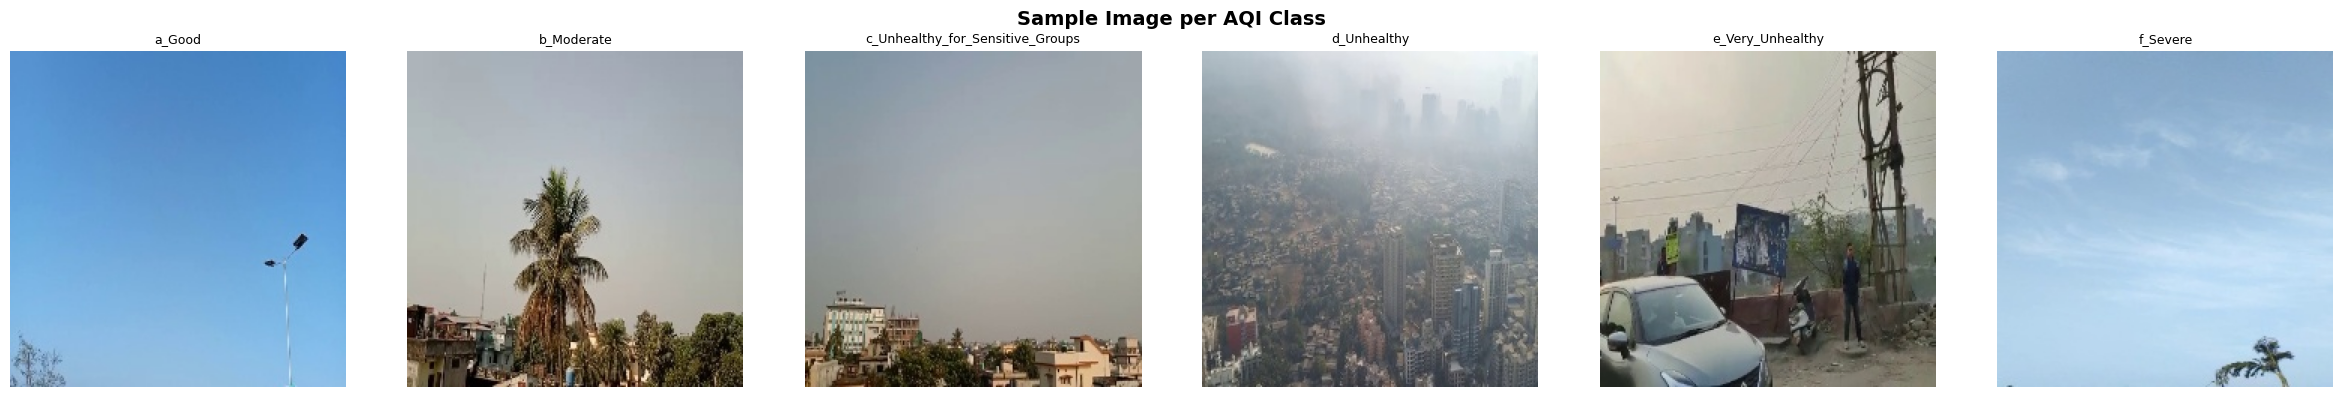

In [6]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
if NUM_CLASSES == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    sample = df[df['AQI_Class'] == cls].sample(1, random_state=SEED).iloc[0]
    img_path = os.path.join(IMAGES_DIR, sample['image_path'])
    try:
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error:\n{e}', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Image per AQI Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Transforms defined.')
print('  Train  : Resize → RandomFlip → RandomRotation → ColorJitter → Tensor → Normalize')
print('  Val/Test: Resize → Tensor → Normalize')

Transforms defined.
  Train  : Resize → RandomFlip → RandomRotation → ColorJitter → Tensor → Normalize
  Val/Test: Resize → Tensor → Normalize


In [8]:
class AQIDataset(Dataset):
    def __init__(self, dataframe, images_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image_path'])
        label    = int(row['label'])

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            # Fallback: return a black image so training doesn't crash
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=0)

        if self.transform:
            image = self.transform(image)

        return image, label


BATCH_SIZE = 32

train_dataset = AQIDataset(train_df, IMAGES_DIR, transform=train_transform)
val_dataset   = AQIDataset(val_df,   IMAGES_DIR, transform=val_test_transform)
test_dataset  = AQIDataset(test_df,  IMAGES_DIR, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 132
Val batches   : 29
Test batches  : 29


## 🧠 Task 2 - Basic CNN Model (Trained from Scratch)
### Cell 2a - Define the CNN Architecture

In [9]:
class LightweightCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 224×224×3 → 112×112×16
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2: 112×112×16 → 56×56×32
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3: 56×56×32 → 28×28×64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))  # 2×2 instead of 4×4

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 2 * 2, 128),   # 256 → 128 instead of 4096 → 512
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x


cnn_model = LightweightCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print()
print(cnn_model)

Total parameters    : 57,478
Trainable parameters: 57,478

LightweightCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(2, 2))
  (classi

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds  = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds  = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return running_loss / total, correct / total


def get_all_predictions(model, loader, device):
    """Returns (true_labels, predicted_labels) as numpy arrays."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


def full_training_loop(model, train_loader, val_loader, num_epochs,
                        lr, device, model_name='model'):
    """Full training loop with early stopping patience=5."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    PATIENCE = 5
    best_model_path = f'best_{model_name}.pth'

    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)

        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        print(f'Epoch [{epoch+1:>3}/{num_epochs}] '
              f'Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | '
              f'Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f}')

        # Save best model
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1}')
                break

    # Reload best weights
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f'\nBest model loaded from {best_model_path}')
    return history


print('Training utilities defined.')

Training utilities defined.


In [11]:
CNN_EPOCHS = 20
CNN_LR     = 0.001

print('Training Basic CNN from Scratch')

cnn_history = full_training_loop(
    model        = cnn_model,
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = CNN_EPOCHS,
    lr           = CNN_LR,
    device       = DEVICE,
    model_name   = 'lightweight_cnn'
)

Training Basic CNN from Scratch
Epoch [  1/20] Train Loss: 1.5154 | Train Acc: 0.3700 | Val Loss: 1.2971 | Val Acc: 0.4900
Epoch [  2/20] Train Loss: 1.2807 | Train Acc: 0.4819 | Val Loss: 1.1397 | Val Acc: 0.5600
Epoch [  3/20] Train Loss: 1.1850 | Train Acc: 0.5214 | Val Loss: 1.0569 | Val Acc: 0.5867
Epoch [  4/20] Train Loss: 1.1177 | Train Acc: 0.5440 | Val Loss: 1.0489 | Val Acc: 0.5678
Epoch [  5/20] Train Loss: 1.0667 | Train Acc: 0.5752 | Val Loss: 0.8996 | Val Acc: 0.6300
Epoch [  6/20] Train Loss: 1.0196 | Train Acc: 0.5862 | Val Loss: 0.9085 | Val Acc: 0.6233
Epoch [  7/20] Train Loss: 0.9623 | Train Acc: 0.6157 | Val Loss: 1.0007 | Val Acc: 0.6089
Epoch [  8/20] Train Loss: 0.9410 | Train Acc: 0.6186 | Val Loss: 0.8422 | Val Acc: 0.6511
Epoch [  9/20] Train Loss: 0.8857 | Train Acc: 0.6455 | Val Loss: 0.7413 | Val Acc: 0.6867
Epoch [ 10/20] Train Loss: 0.8668 | Train Acc: 0.6555 | Val Loss: 0.7357 | Val Acc: 0.6989
Epoch [ 11/20] Train Loss: 0.8655 | Train Acc: 0.6486 | Va

## Task 3 - Pretrained CNN (MobileNetV2)

In [12]:
# Load pretrained weights
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Phase 1: Freeze ALL base layers
for param in mobilenet.parameters():
    param.requires_grad = False

# Replace the classifier head
in_features = mobilenet.classifier[1].in_features   # 1280

mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

mobilenet = mobilenet.to(DEVICE)

# Parameter count
total    = sum(p.numel() for p in mobilenet.parameters())
trainable= sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}  ({trainable/total*100:.1f}% of total)')
print('\nClassifier head:')
print(mobilenet.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\dmist/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:02<00:00, 5.79MB/s]

Total parameters    : 2,553,350
Trainable parameters: 329,478  (12.9% of total)

Classifier head:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=6, bias=True)
)


In [13]:
print('Phase 1: Training MobileNetV2 - Classifier Head Only (Frozen Backbone)')

mobilenet_history_p1 = full_training_loop(
    model        = mobilenet,
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = 10,
    lr           = 1e-3,
    device       = DEVICE,
    model_name   = 'mobilenet_phase1'
)

Phase 1: Training MobileNetV2 — Classifier Head Only (Frozen Backbone)
Epoch [  1/10] Train Loss: 1.3749 | Train Acc: 0.4498 | Val Loss: 1.0825 | Val Acc: 0.5711
Epoch [  2/10] Train Loss: 1.0481 | Train Acc: 0.5893 | Val Loss: 0.8897 | Val Acc: 0.6489
Epoch [  3/10] Train Loss: 0.9419 | Train Acc: 0.6302 | Val Loss: 0.7938 | Val Acc: 0.6767
Epoch [  4/10] Train Loss: 0.8489 | Train Acc: 0.6643 | Val Loss: 0.7779 | Val Acc: 0.6689
Epoch [  5/10] Train Loss: 0.8101 | Train Acc: 0.6843 | Val Loss: 0.6975 | Val Acc: 0.7278
Epoch [  6/10] Train Loss: 0.7549 | Train Acc: 0.7088 | Val Loss: 0.7001 | Val Acc: 0.7267
Epoch [  7/10] Train Loss: 0.7375 | Train Acc: 0.7093 | Val Loss: 0.5813 | Val Acc: 0.7667
Epoch [  8/10] Train Loss: 0.7130 | Train Acc: 0.7236 | Val Loss: 0.6113 | Val Acc: 0.7722
Epoch [  9/10] Train Loss: 0.6884 | Train Acc: 0.7326 | Val Loss: 0.5799 | Val Acc: 0.7867
Epoch [ 10/10] Train Loss: 0.6859 | Train Acc: 0.7331 | Val Loss: 0.5491 | Val Acc: 0.7911

Best model loaded 

In [14]:
UNFREEZE_FROM = 15

for i, layer in enumerate(mobilenet.features):
    if i >= UNFREEZE_FROM:
        for param in layer.parameters():
            param.requires_grad = True

trainable_p2 = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
print(f'Trainable parameters after unfreezing layers {UNFREEZE_FROM}+: {trainable_p2:,}')

print('Phase 2: Fine-tuning MobileNetV2 - Unfrozen Top Blocks + Classifier')


mobilenet_history_p2 = full_training_loop(
    model        = mobilenet,
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = 15,
    lr           = 1e-4,
    device       = DEVICE,
    model_name   = 'mobilenet_phase2'
)

# Merge histories from both phases for plotting
mobilenet_history = {
    key: mobilenet_history_p1[key] + mobilenet_history_p2[key]
    for key in mobilenet_history_p1
}

Trainable parameters after unfreezing layers 15+: 1,855,558
Phase 2: Fine-tuning MobileNetV2 — Unfrozen Top Blocks + Classifier
Epoch [  1/15] Train Loss: 0.5422 | Train Acc: 0.7807 | Val Loss: 0.3606 | Val Acc: 0.8678
Epoch [  2/15] Train Loss: 0.3999 | Train Acc: 0.8448 | Val Loss: 0.2888 | Val Acc: 0.8889
Epoch [  3/15] Train Loss: 0.3305 | Train Acc: 0.8736 | Val Loss: 0.2806 | Val Acc: 0.8956
Epoch [  4/15] Train Loss: 0.2697 | Train Acc: 0.9017 | Val Loss: 0.2402 | Val Acc: 0.9011
Epoch [  5/15] Train Loss: 0.2469 | Train Acc: 0.9148 | Val Loss: 0.2085 | Val Acc: 0.9344
Epoch [  6/15] Train Loss: 0.2062 | Train Acc: 0.9257 | Val Loss: 0.2110 | Val Acc: 0.9233
Epoch [  7/15] Train Loss: 0.1912 | Train Acc: 0.9245 | Val Loss: 0.1691 | Val Acc: 0.9478
Epoch [  8/15] Train Loss: 0.1493 | Train Acc: 0.9483 | Val Loss: 0.1439 | Val Acc: 0.9522
Epoch [  9/15] Train Loss: 0.1334 | Train Acc: 0.9531 | Val Loss: 0.1840 | Val Acc: 0.9311
Epoch [ 10/15] Train Loss: 0.1241 | Train Acc: 0.9529

## Task 4 - Model Evaluation

In [16]:
# Get predictions from both models
y_true_cnn, y_pred_cnn         = get_all_predictions(cnn_model,  test_loader, DEVICE)
y_true_mob, y_pred_mob         = get_all_predictions(mobilenet,  test_loader, DEVICE)

def print_metrics(y_true, y_pred, model_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f'\n{model_name}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (macro)')
    print(f'  Recall    : {rec:.4f}  (macro)')
    print(f'  F1-Score  : {f1:.4f}  (macro)')
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=classes, zero_division=0))
    return acc, prec, rec, f1

cnn_metrics = print_metrics(y_true_cnn, y_pred_cnn, 'Basic CNN (Scratch)')
mob_metrics = print_metrics(y_true_mob, y_pred_mob, 'MobileNetV2 (Transfer Learning)')


Basic CNN (Scratch)
  Accuracy  : 0.7344
  Precision : 0.7418  (macro)
  Recall    : 0.7344  (macro)
  F1-Score  : 0.7258  (macro)

                                  precision    recall  f1-score   support

                          a_Good       0.83      0.70      0.76       150
                      b_Moderate       0.61      0.84      0.71       150
c_Unhealthy_for_Sensitive_Groups       0.66      0.37      0.47       150
                     d_Unhealthy       0.65      0.78      0.71       150
                e_Very_Unhealthy       0.81      0.79      0.80       150
                        f_Severe       0.89      0.93      0.91       150

                        accuracy                           0.73       900
                       macro avg       0.74      0.73      0.73       900
                    weighted avg       0.74      0.73      0.73       900


MobileNetV2 (Transfer Learning)
  Accuracy  : 0.9756
  Precision : 0.9758  (macro)
  Recall    : 0.9756  (macro)
  F1-Score

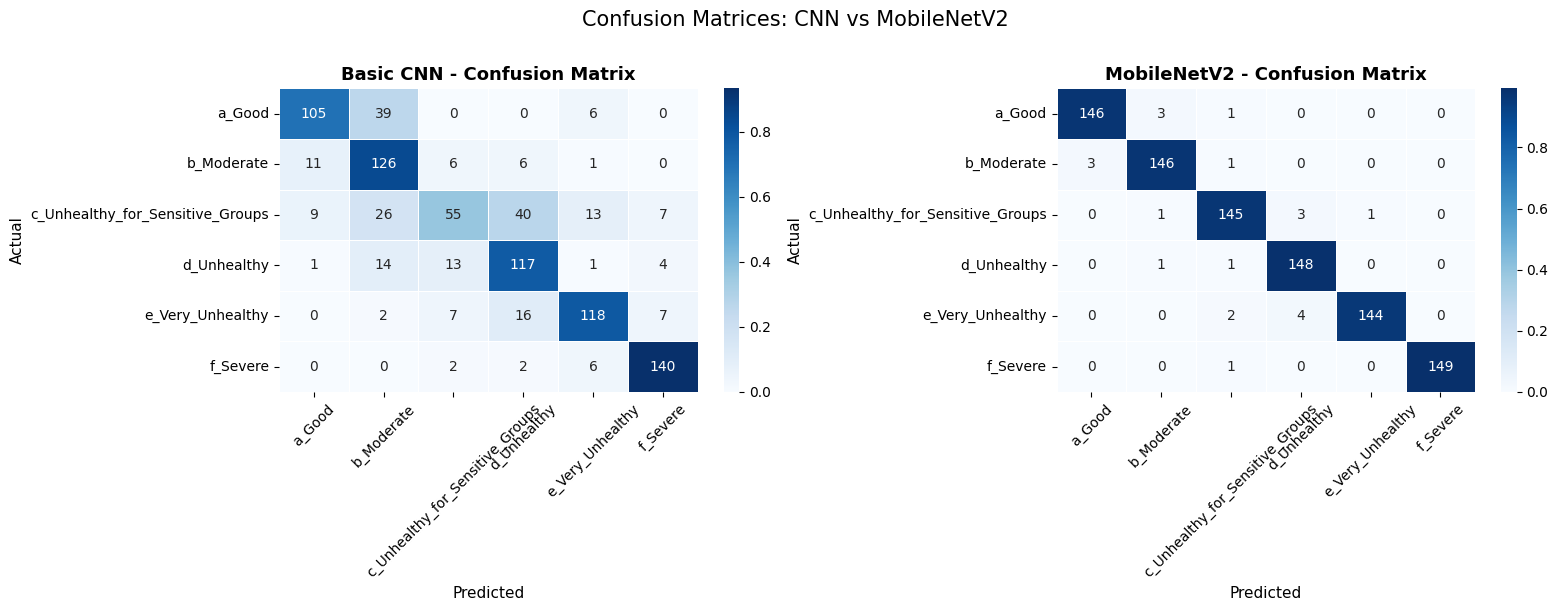

In [17]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalise

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_confusion_matrix(y_true_cnn, y_pred_cnn, classes,
                       'Basic CNN - Confusion Matrix', axes[0])
plot_confusion_matrix(y_true_mob, y_pred_mob, classes,
                       'MobileNetV2 - Confusion Matrix', axes[1])

plt.suptitle('Confusion Matrices: CNN vs MobileNetV2', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
metrics_labels = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']

comparison_df = pd.DataFrame({
    'Metric'      : metrics_labels,
    'Basic CNN'   : [f'{v:.4f}' for v in cnn_metrics],
    'MobileNetV2' : [f'{v:.4f}' for v in mob_metrics]
})

print(comparison_df.to_string(index=False))
comparison_df.to_csv('model_comparison.csv', index=False)
print('\nSaved to model_comparison.csv')

           Metric Basic CNN MobileNetV2
         Accuracy    0.7344      0.9756
Precision (macro)    0.7418      0.9758
   Recall (macro)    0.7344      0.9756
 F1-Score (macro)    0.7258      0.9756

Saved to model_comparison.csv


## Task 5 - Training Curves

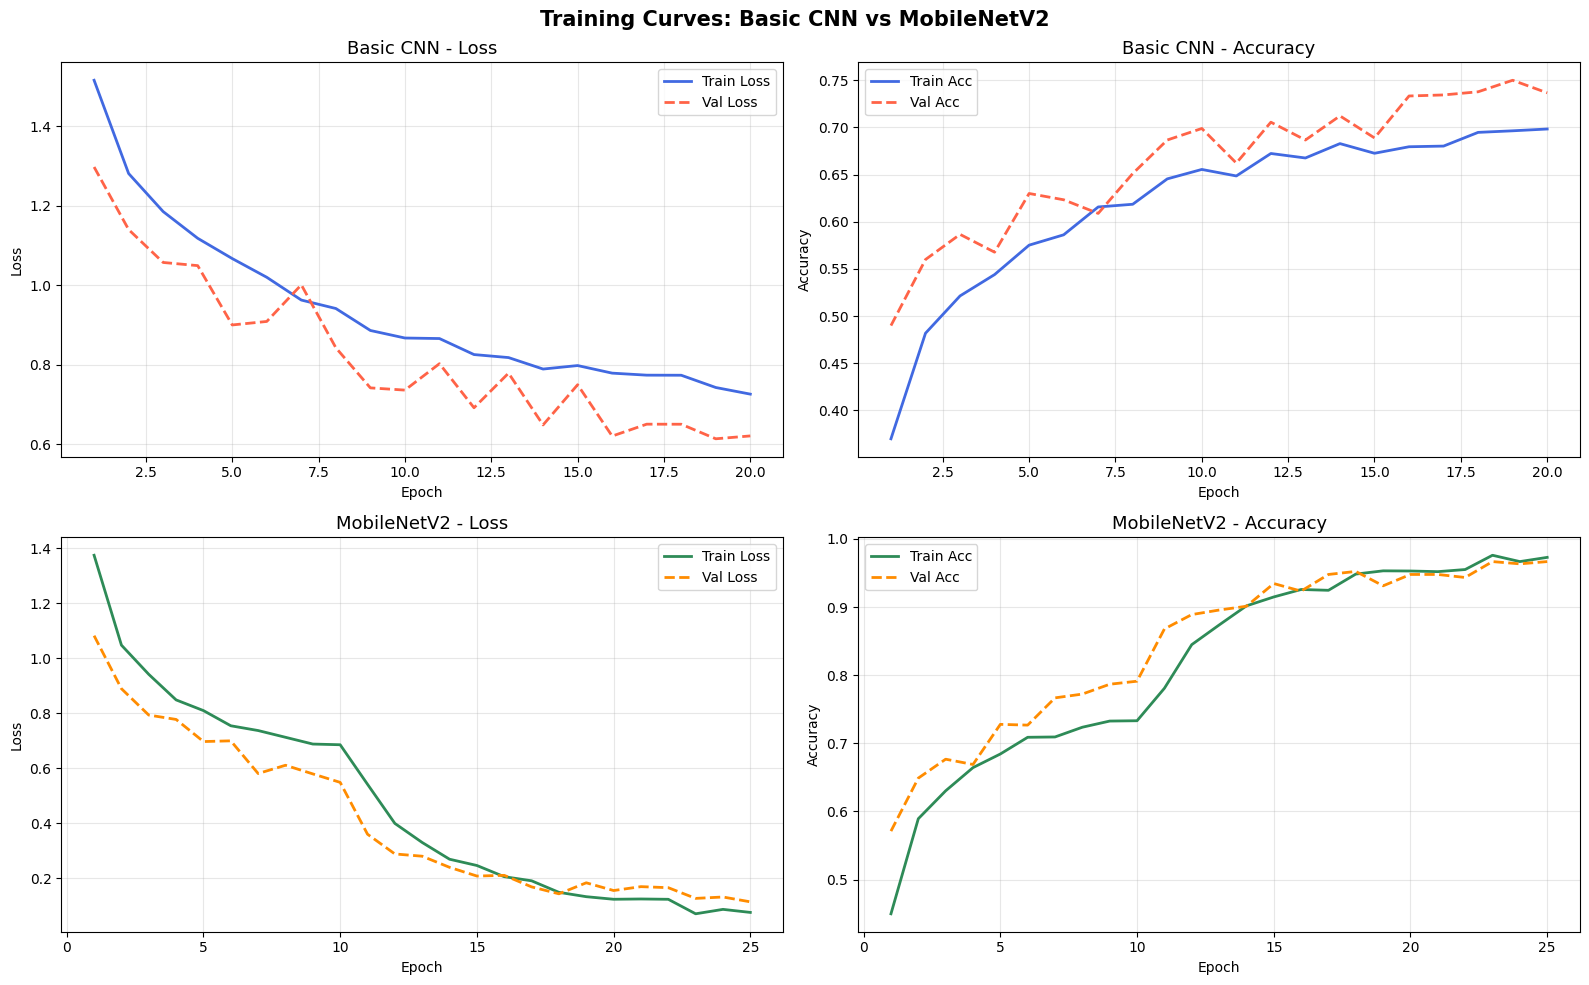

In [19]:
def plot_training_curves(history, model_name, color_train='royalblue',
                          color_val='tomato', axes=None):
    epochs = range(1, len(history['train_loss']) + 1)

    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history['train_loss'], color=color_train, label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'],   color=color_val,   label='Val Loss',   linewidth=2, linestyle='--')
    axes[0].set_title(f'{model_name} - Loss', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], color=color_train, label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'],   color=color_val,   label='Val Acc',   linewidth=2, linestyle='--')
    axes[1].set_title(f'{model_name} - Accuracy', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    return axes


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_training_curves(cnn_history,       'Basic CNN',   axes=axes[0])
plot_training_curves(mobilenet_history, 'MobileNetV2', color_train='seagreen',
                      color_val='darkorange', axes=axes[1])

plt.suptitle('Training Curves: Basic CNN vs MobileNetV2', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Training Curves & Model Comparison – Summary

The results clearly show that MobileNetV2 performs much better than the Basic CNN. Across all metrics (accuracy, precision, recall, and F1-score), MobileNetV2 improves performance by about 24%, which indicates a significant advantage rather than random variation.

For the Basic CNN, training and validation accuracy increase slowly and plateau around 70–74%. Validation metrics are slightly higher than training because Dropout is active during training but disabled during validation. Overall, the model shows signs of underfitting, meaning it struggles to learn strong visual features from the limited dataset.

In contrast, MobileNetV2 converges quickly and reaches about 95–97% accuracy. Training and validation curves closely follow each other, indicating stable learning with no major overfitting. The transfer learning approach allows the model to use pretrained ImageNet features, which helps it recognise haze patterns and atmospheric details more effectively.

The confusion matrix highlights this difference: the Basic CNN struggles with middle AQI classes, especially Unhealthy for Sensitive Groups, while MobileNetV2 classifies almost all categories correctly.

Overall, transfer learning is clearly the better approach for this task because the dataset is relatively small and the visual patterns overlap with natural images already learned by pretrained models.

## Task 6 - Misclassification Analysis

In [20]:
def get_misclassified_samples(model, loader, dataframe, device, n=10):
    model.eval()
    misclassified = []

    with torch.no_grad():
        global_idx = 0
        for images, labels in loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            preds = outputs.argmax(dim=1).cpu().numpy()
            labels_np = labels.numpy()

            for i in range(len(labels_np)):
                if preds[i] != labels_np[i]:
                    misclassified.append({
                        'df_idx'    : global_idx + i,
                        'image_path': dataframe.iloc[global_idx + i]['image_path'],
                        'actual'    : idx_to_class[labels_np[i]],
                        'predicted' : idx_to_class[preds[i]]
                    })
                    if len(misclassified) >= n * 3:  # collect more than needed
                        break
            global_idx += len(labels_np)
            if len(misclassified) >= n * 3:
                break

    return misclassified[:n]


misclassified = get_misclassified_samples(
    mobilenet, test_loader, test_df, DEVICE, n=10
)

print(f'Misclassified samples found: {len(misclassified)}')
for m in misclassified:
    print(f"  {m['image_path'][:50]:50s} | Actual: {m['actual']:20s} | Pred: {m['predicted']}")

Misclassified samples found: 10
  BENGR_UHFSG_2023-02-14-08.30-1-20.jpg              | Actual: c_Unhealthy_for_Sensitive_Groups | Pred: b_Moderate
  TN_UnFSG_2023-03-02-08.30-1-186.jpg                | Actual: c_Unhealthy_for_Sensitive_Groups | Pred: d_Unhealthy
  BIR_UNH_VF_2023-02-03- 10.00-1-55.jpg              | Actual: d_Unhealthy          | Pred: b_Moderate
  MH_UnFSG_2023-02-23-11.00-1-276.jpg                | Actual: c_Unhealthy_for_Sensitive_Groups | Pred: e_Very_Unhealthy
  BENGR_Mod_2023-02-23-08.30-1-36.jpg                | Actual: b_Moderate           | Pred: c_Unhealthy_for_Sensitive_Groups
  BENGR_Mod_2023-03-01-08.30-1-176.jpg               | Actual: b_Moderate           | Pred: a_Good
  BENGR_Good_2023-02-26-08.30-1-196.jpg              | Actual: a_Good               | Pred: b_Moderate
  BENGR_Mod_2023-03-06-08.30-1-576.jpg               | Actual: b_Moderate           | Pred: a_Good
  BENGR_Good_2023-02-19-08.30-1-4.jpg                | Actual: a_Good               | P

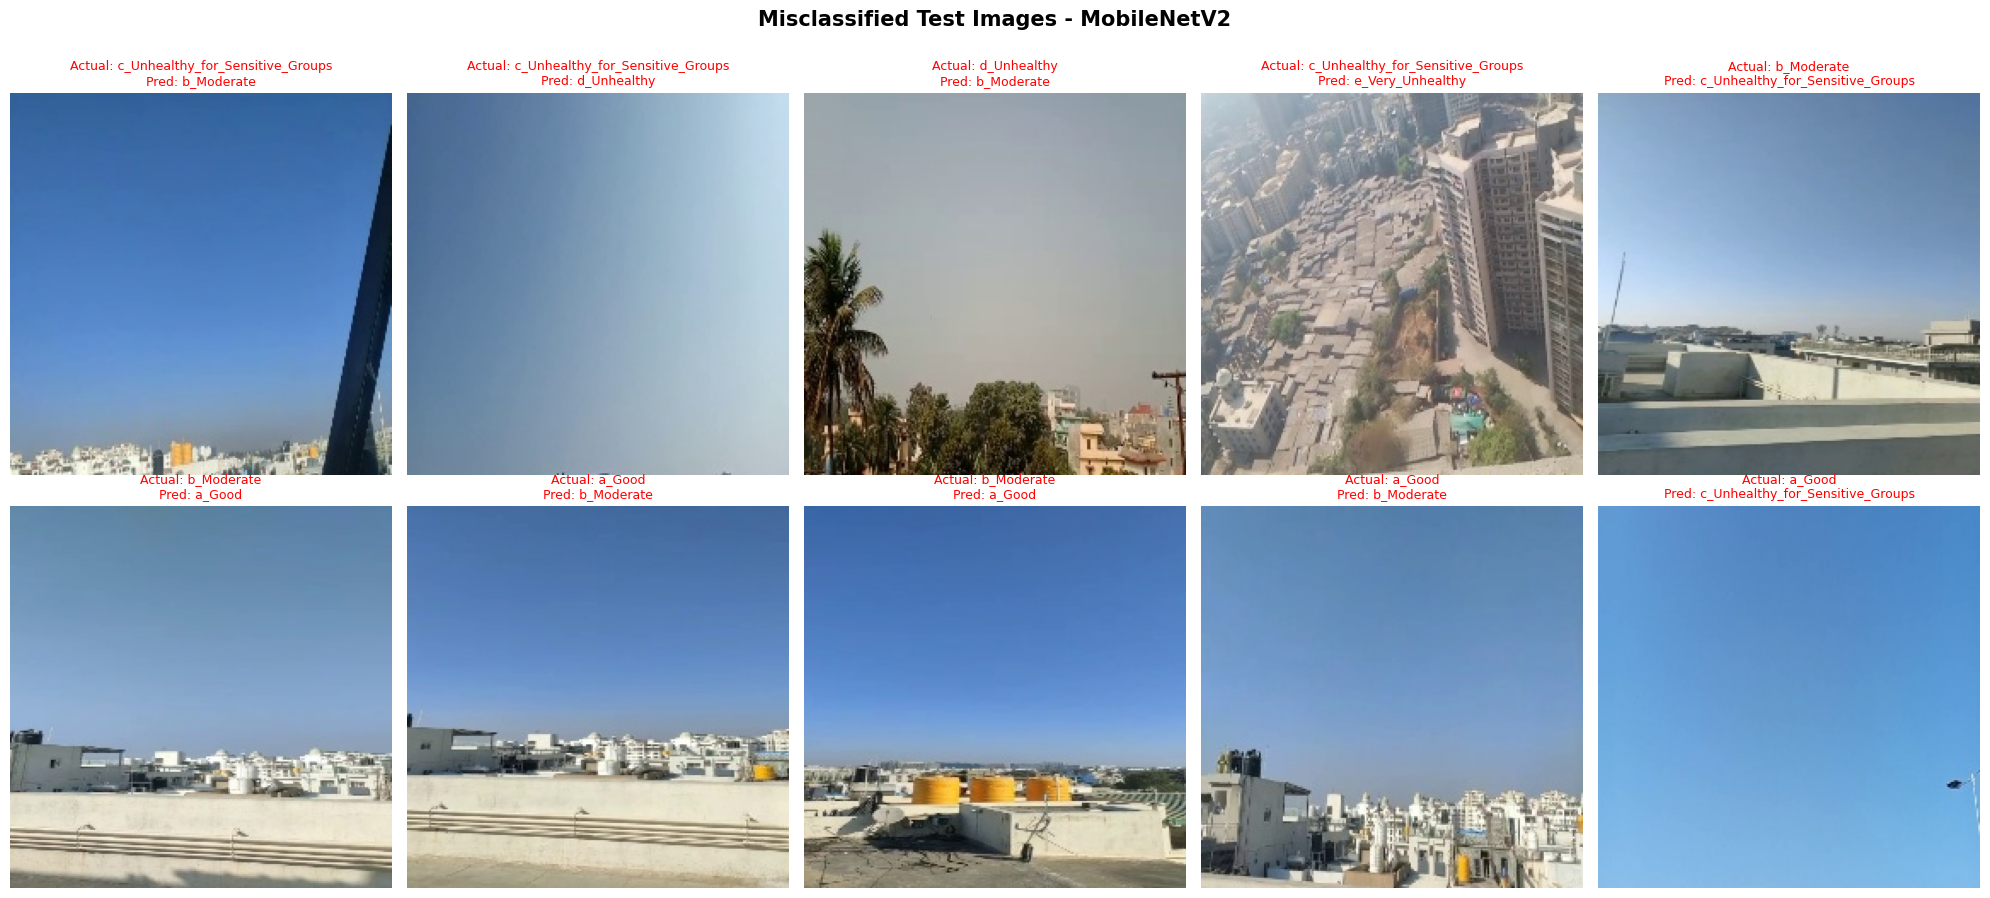

In [21]:
n_show = min(10, len(misclassified))
n_cols = 5
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for i in range(n_show):
    sample = misclassified[i]
    img_path = os.path.join(IMAGES_DIR, sample['image_path'])

    try:
        img = Image.open(img_path).convert('RGB')
        axes[i].imshow(img)
    except Exception as e:
        axes[i].text(0.5, 0.5, str(e), ha='center', va='center',
                      transform=axes[i].transAxes, fontsize=8)

    axes[i].set_title(
        f'Actual: {sample["actual"]}\nPred: {sample["predicted"]}',
        fontsize=9, color='green' if sample['actual'] == sample['predicted'] else 'red'
    )
    axes[i].axis('off')

# Hide any extra axes
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Misclassified Test Images - MobileNetV2', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('misclassified_images.png', dpi=120, bbox_inches='tight')
plt.show()

# Task 6 - Misclassification Analysis (MobileNetV2)

---

## 6.1 Misclassified Samples

| Image | Actual | Predicted |
|---|---|---|
| BENGR_UHFSG_2023-02-14-08.30-1-20.jpg | c_Unhealthy_for_Sensitive_Groups | b_Moderate |
| TN_UnFSG_2023-03-02-08.30-1-186.jpg | c_Unhealthy_for_Sensitive_Groups | d_Unhealthy |
| BIR_UNH_VF_2023-02-03-10.00-1-55.jpg | d_Unhealthy | b_Moderate |
| MH_UnFSG_2023-02-23-11.00-1-276.jpg | c_Unhealthy_for_Sensitive_Groups | e_Very_Unhealthy |
| BENGR_Mod_2023-02-23-08.30-1-36.jpg | b_Moderate | c_Unhealthy_for_Sensitive_Groups |
| BENGR_Mod_2023-03-01-08.30-1-176.jpg | b_Moderate | a_Good |
| BENGR_Good_2023-02-26-08.30-1-196.jpg | a_Good | b_Moderate |
| BENGR_Mod_2023-03-06-08.30-1-576.jpg | b_Moderate | a_Good |
| BENGR_Good_2023-02-19-08.30-1-4.jpg | a_Good | b_Moderate |
| TN_Good_2023-02-23-08.30-2-81.jpg | a_Good | c_Unhealthy_for_Sensitive_Groups |

---

## 6.2 Patterns Observed

**1. Adjacent class confusion is the dominant error pattern.**
9 out of 10 misclassifications are between neighbouring AQI categories - Good↔Moderate, Moderate↔Unhealthy_for_Sensitive_Groups, Unhealthy↔Moderate. The model never confuses Good with Severe or Unhealthy with Good. This confirms the errors are not random - they are systematic boundary failures where visual difference between consecutive AQI levels is minimal.

**2. The images visually justify the confusion.**
Looking at the actual images, the misclassified samples are genuinely ambiguous:
- Images labelled `a_Good` and `b_Moderate` both show clear blue skies with similar brightness and haze levels - a human observer looking at just the image would likely disagree with the label too.
- The `d_Unhealthy` image predicted as `b_Moderate` shows a hazy sky over trees, but the haze level is visually subtle enough that the model underestimates it.
- The `c_Unhealthy_for_Sensitive_Groups` image predicted as `e_Very_Unhealthy` (Image 4 - aerial city shot) has a dense grey overlay that visually resembles a worse AQI class.

**3. The label itself cannot always be inferred from the image alone.**
Several `a_Good` and `b_Moderate` images look identical to the human eye - both show clear blue skies over rooftops (bottom row, images 2, 3, 4). The AQI value in the CSV may reflect sensor readings that don't have a visible counterpart in the image. The model is correct to be uncertain here - the image simply does not contain enough signal to distinguish these classes reliably.


## Final Summary

In [24]:
print("FINAL RESULTS SUMMARY")

print(comparison_df.to_string(index=False))
print()
print("Files saved:")
for f in ['sample_images_per_class.png', 'confusion_matrices.png',
          'training_curves.png', 'misclassified_images.png',
          'model_comparison.csv', 'best_basic_cnn.pth', 'best_mobilenet_phase2.pth']:
    print(f"  • {f}")


FINAL RESULTS SUMMARY
           Metric Basic CNN MobileNetV2
         Accuracy    0.7344      0.9756
Precision (macro)    0.7418      0.9758
   Recall (macro)    0.7344      0.9756
 F1-Score (macro)    0.7258      0.9756

Files saved:
  • sample_images_per_class.png
  • confusion_matrices.png
  • training_curves.png
  • misclassified_images.png
  • model_comparison.csv
  • best_basic_cnn.pth
  • best_mobilenet_phase2.pth
